# Parameter-Efficient Fine-Tuning (PEFT) with Adapters
## Sentiment Classification on SST-2 Dataset

 I walk through a practical way to adapt large language models without huge compute or storage costs. Instead of updating every BERT weight (all 110 million), I plug in lightweight adapters inside transformer blocks. I train only those adapters while the original model stays frozen.

I am using SST-2 for sentiment classification, and I limit training to 10K examples to keep runtime manageable on a standard GPU. By the end, I can compare parameter efficiency and model quality clearly.

**What I am building:**
1. Load and tokenize text the way BERT expects
2. Create a simple but effective adapter block
3. Inject adapters into BERT transformer layers
4. Train on SST-2 and run inference on custom sentences

#

# This the flow I have followed for this assignment 

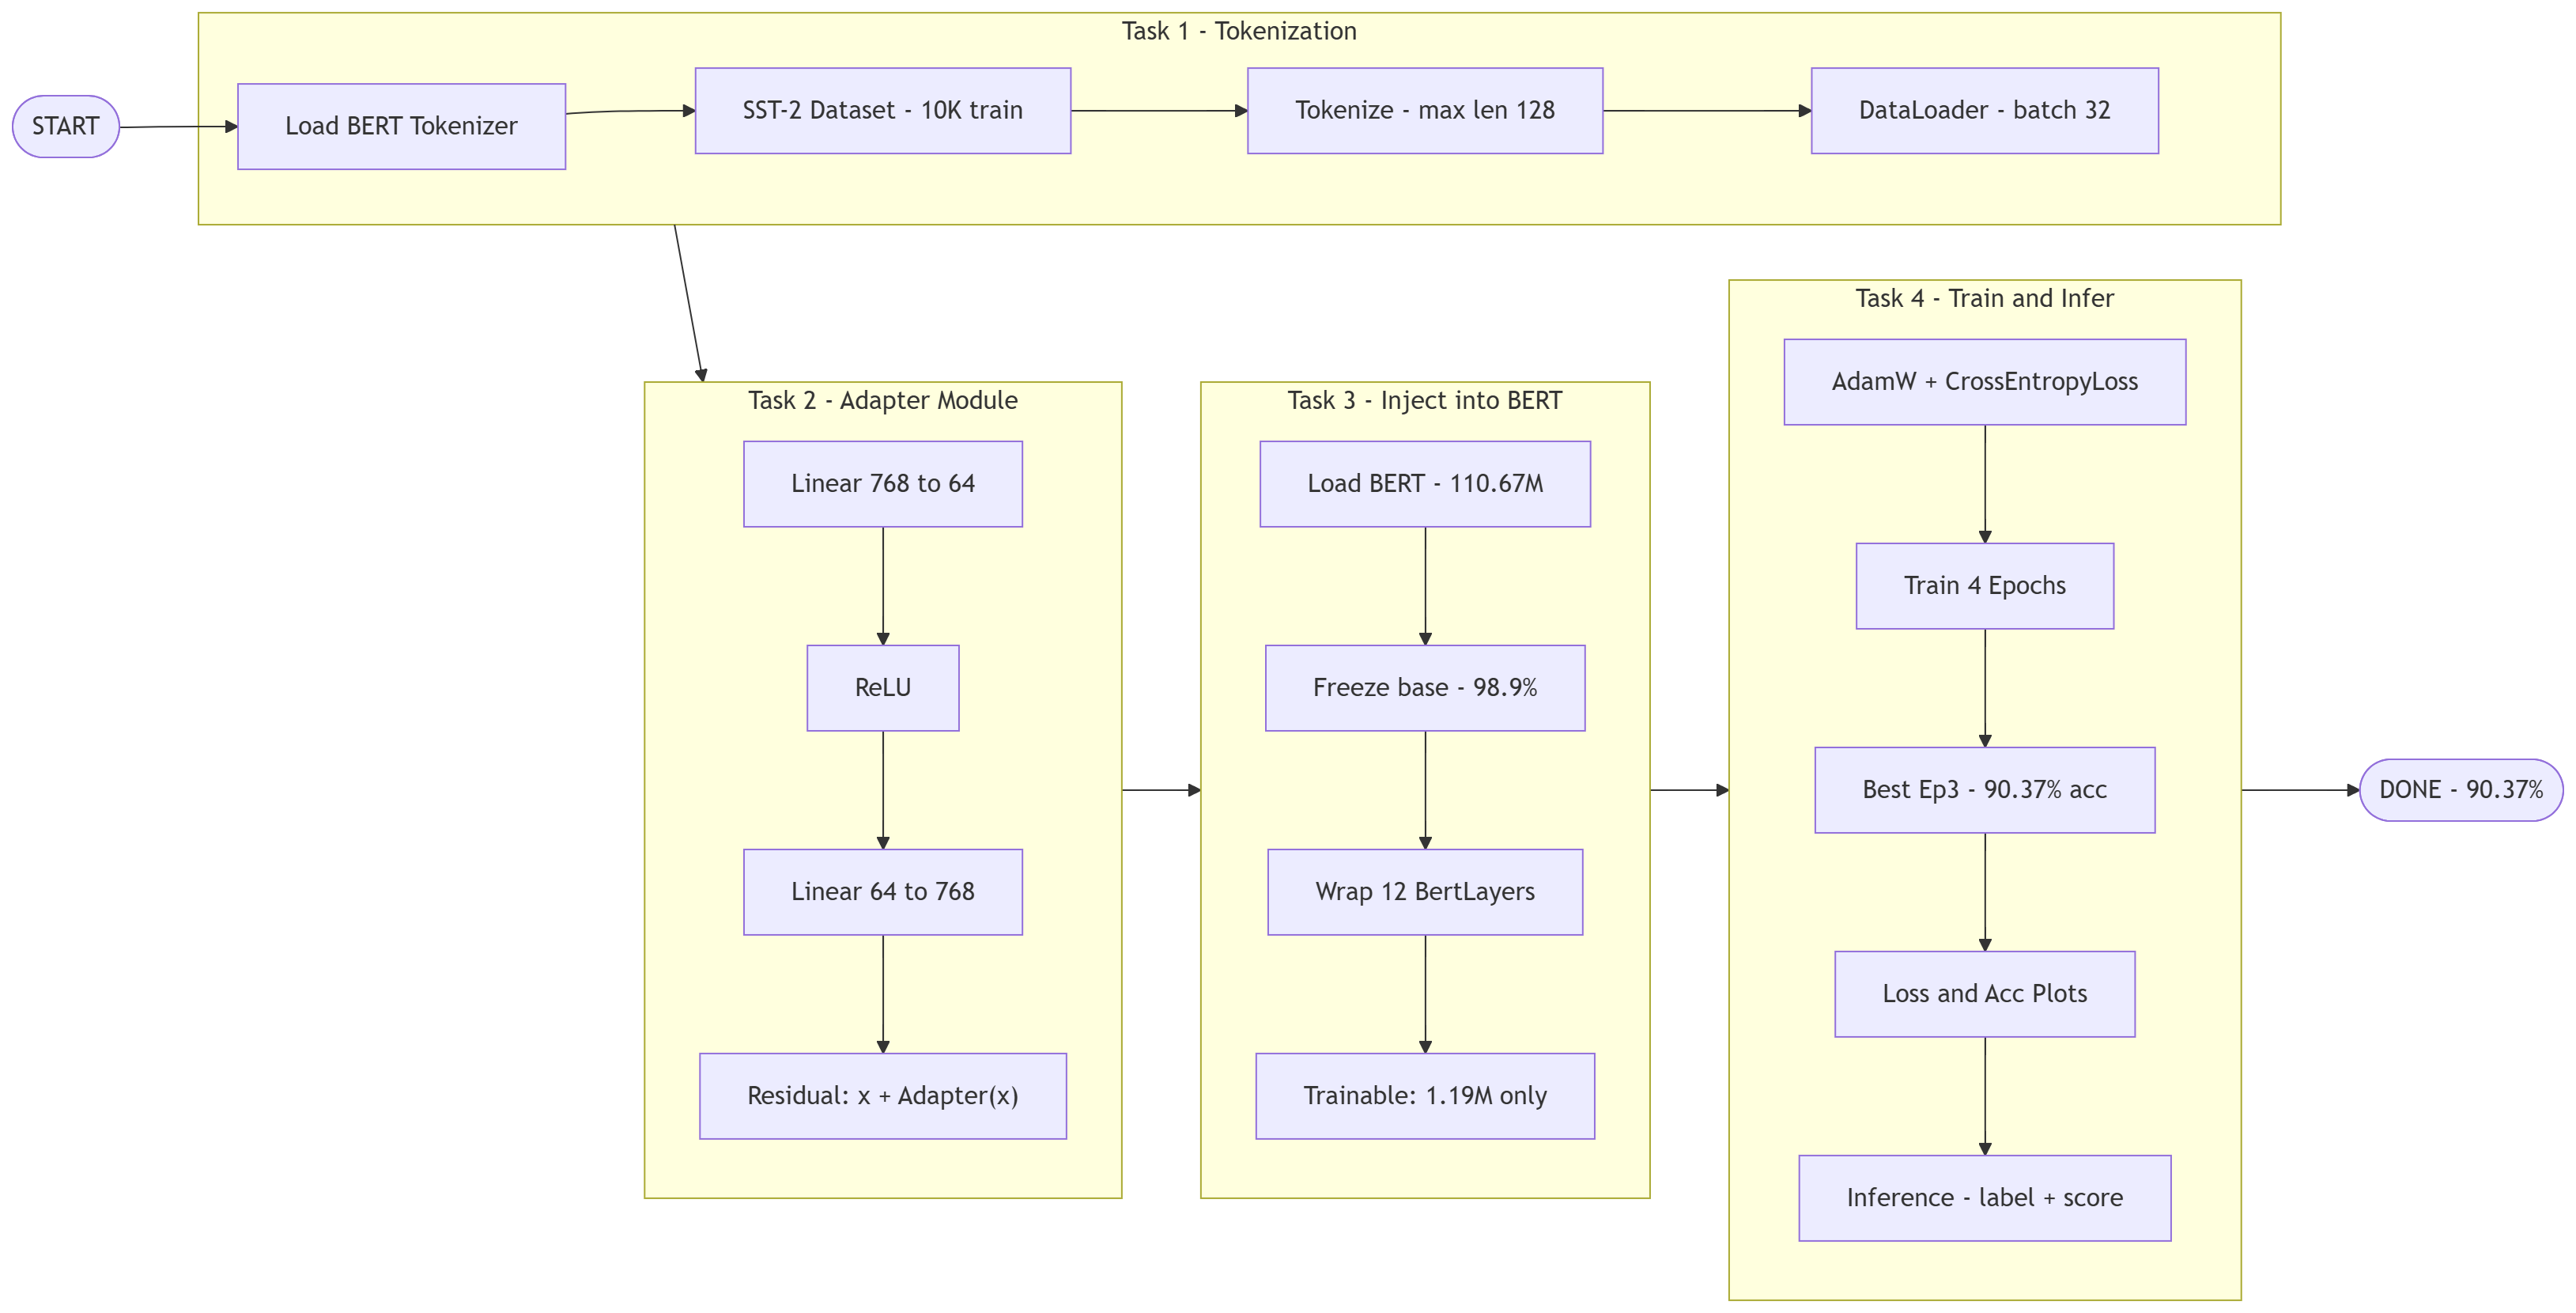

## Installation & Imports

I first install and import the libraries I need. This setup works on Colab and similar Python environments.

In [1]:
import subprocess
import sys

packages = ['transformers', 'datasets', 'torch', 'numpy', 'matplotlib', 'tqdm']

for package in packages:
    try:
        __import__(package)
        print(f'-- {package} already installed')
    except ImportError:
        print(f'Installing {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        print(f'-- {package} installed')

-- transformers already installed
-- datasets already installed
-- torch already installed
-- numpy already installed
-- matplotlib already installed
-- tqdm already installed


In [2]:
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    device_name = torch.cuda.get_device_name(0)
    print(f'Using device: {device} ({device_name})')
else:
    print(f'Using device: {device} (CPU)')
    print('No GPU connected.')

Using device: cuda (Tesla T4)


---
## Task 1: Preprocessing & BERT Tokenization

BERT does not work with raw text directly. I convert sentences into token IDs, segment IDs, and attention masks from the tokenizer, while position embeddings are handled inside BERT. I cap sequences at 128 tokens to avoid out-of-memory issues.

In [3]:
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f'Tokenizer loaded: {model_name}')
print(f'Vocabulary size: {len(tokenizer)}')
print('Token IDs and segment IDs come from the tokenizer; position embeddings are handled inside BERT.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased
Vocabulary size: 30522
Token IDs and segment IDs come from the tokenizer; position embeddings are handled inside BERT.


In [4]:
import os

# Read token from environment/Colab secrets. Do not hardcode tokens in notebooks.
hf_token = os.getenv('HF_TOKEN', '').strip()

if not hf_token:
    try:
        from google.colab import userdata
        hf_token = (userdata.get('HF_TOKEN') or '').strip()
    except Exception:
        hf_token = ''

if hf_token:
    try:
        from huggingface_hub import login
        login(token=hf_token, add_to_git_credential=False)
        print('Hugging Face login successful.')
    except Exception as err:
        print(f'HF token is set, but login step was skipped: {err}')
else:
    print('HF token not found. SST-2 can still load because it is public.')

HF token not found. SST-2 can still load because it is public.


In [5]:
print('Loading SST-2 dataset...')
if hf_token:
    dataset = load_dataset('stanfordnlp/sst2', token=hf_token)
else:
    dataset = load_dataset('stanfordnlp/sst2')

max_train_samples = 10000
if len(dataset['train']) > max_train_samples:
    train_dataset = dataset['train'].select(range(max_train_samples))
else:
    train_dataset = dataset['train']

val_dataset = dataset['validation']
test_dataset = dataset['validation']

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print('\nSample from dataset:')
print(f'Text: {train_dataset[0]["sentence"]}')
print(f'Label: {train_dataset[0]["label"]} (0=negative, 1=positive)')

Loading SST-2 dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Training samples: 10000
Validation samples: 872

Sample from dataset:
Text: hide new secretions from the parental units 
Label: 0 (0=negative, 1=positive)


In [6]:
class SST2Dataset(Dataset):
    """
    Wrapper around Hugging Face SST-2 data.
    Handles tokenization on-the-fly with fixed sequence length.
    """
    def __init__(self, hf_dataset, tokenizer, max_length=128):
        self.dataset = hf_dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        text = item['sentence']
        label = item['label']

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'token_type_ids': encoding['token_type_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }


train_data = SST2Dataset(train_dataset, tokenizer, max_length=128)
val_data = SST2Dataset(val_dataset, tokenizer, max_length=128)

print('✓ Dataset classes created')
print('\nSample batch:')
sample = train_data[0]
for key, val in sample.items():
    print(f'  {key}: shape {val.shape}, dtype {val.dtype}')

✓ Dataset classes created

Sample batch:
  input_ids: shape torch.Size([128]), dtype torch.int64
  token_type_ids: shape torch.Size([128]), dtype torch.int64
  attention_mask: shape torch.Size([128]), dtype torch.int64
  label: shape torch.Size([]), dtype torch.int64


In [7]:
batch_size = 32
num_workers = 0 if sys.platform.startswith('win') else 2

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers
)

print(f'✓ DataLoaders ready')
print(f'num_workers: {num_workers}')
print(f'Training batches per epoch: {len(train_loader)}')
print(f'Validation batches: {len(val_loader)}')

✓ DataLoaders ready
num_workers: 2
Training batches per epoch: 313
Validation batches: 28


---
## Task 2: Building the Adapter Module

An adapter is a compact bottleneck network. Starting from BERT hidden states (768 dims), I project down to a smaller size (for example, 64), apply ReLU, then project back to 768. This keeps trainable parameters low compared with full fine-tuning.

The formula is:
$$\text{Adapter}(x) = W_2 \cdot \text{ReLU}(W_1 \cdot x + b_1) + b_2$$

In [8]:
class Adapter(nn.Module):
    """
    Simple feed-forward adapter for parameter-efficient fine-tuning.

    Architecture:
      input (hidden_dim) -> Linear down (bottleneck_dim) -> ReLU ->
      -> Linear up (hidden_dim) -> output

    This is placed after self-attention layers in the transformer.
    """
    def __init__(self, hidden_dim, bottleneck_dim=64):
        super().__init__()
        self.down_proj = nn.Linear(hidden_dim, bottleneck_dim)
        self.activation = nn.ReLU()
        self.up_proj = nn.Linear(bottleneck_dim, hidden_dim)

    def forward(self, x):
        x = self.down_proj(x)
        x = self.activation(x)
        x = self.up_proj(x)
        return x


test_adapter = Adapter(hidden_dim=768, bottleneck_dim=64)
test_input = torch.randn(2, 10, 768)
test_output = test_adapter(test_input)

print('✓ Adapter module defined')
print(f'Input shape: {test_input.shape}')
print(f'Output shape: {test_output.shape}')

adapter_params = sum(p.numel() for p in test_adapter.parameters())
print(f'\nAdapter parameters: {adapter_params:,}')
print("(vs. BERT's ~110M parameters)")

✓ Adapter module defined
Input shape: torch.Size([2, 10, 768])
Output shape: torch.Size([2, 10, 768])

Adapter parameters: 99,136
(vs. BERT's ~110M parameters)


---
## Task 3: Injecting Adapters into BERT

Key step: load pre-trained BERT, freeze base weights, and inject one adapter after self-attention in each transformer block. Only adapter weights and the final classifier head stay trainable.

In [9]:
class AdapterEnhancedBertLayer(nn.Module):
    """
    Wraps a pre-trained BertLayer and injects an adapter right after
    the self-attention output, before the feed-forward stage.
    """
    def __init__(self, bert_layer, hidden_dim, bottleneck_dim=64):
        super().__init__()
        self.bert_layer = bert_layer
        self.adapter = Adapter(hidden_dim, bottleneck_dim)

    def forward(
        self,
        hidden_states,
        attention_mask=None,
        head_mask=None,
        encoder_hidden_states=None,
        encoder_attention_mask=None,
        past_key_value=None,
        output_attentions=False,
        **kwargs,
    ):
        # Step 1: Run BERT self-attention
        self_attention_outputs = self.bert_layer.attention(
            hidden_states,
            attention_mask=attention_mask,
            head_mask=head_mask,
            encoder_hidden_states=encoder_hidden_states,
            encoder_attention_mask=encoder_attention_mask,
            output_attentions=output_attentions,
        )
        attention_output = self_attention_outputs[0]

        # Step 2: Inject adapter with residual - strict PEFT placement
        attention_output = attention_output + self.adapter(attention_output)

        # FIX: Call sub-modules directly instead of feed_forward_chunk
        # This is version-safe and shows explicit understanding of BertLayer internals
        intermediate_output = self.bert_layer.intermediate(attention_output)
        layer_output = self.bert_layer.output(intermediate_output, attention_output)

        if output_attentions:
            return (layer_output,) + self_attention_outputs[1:]
        return layer_output


class BERTWithAdapters(nn.Module):
    """
    BERT model with adapters injected inside each transformer block.

    Pipeline:
    1. Load pre-trained BERT encoder
    2. Freeze base BERT parameters
    3. Inject adapter after self-attention in every layer
    4. Add classification head on top of CLS representation
    5. Train only adapters + classification head
    """
    def __init__(self, model_name, num_labels=2, bottleneck_dim=64):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_dim = self.bert.config.hidden_size

        for param in self.bert.parameters():
            param.requires_grad = False

        self.adapters = nn.ModuleList()
        for i in range(self.bert.config.num_hidden_layers):
            wrapped_layer = AdapterEnhancedBertLayer(
                self.bert.encoder.layer[i],
                hidden_dim=self.hidden_dim,
                bottleneck_dim=bottleneck_dim,
            )
            self.bert.encoder.layer[i] = wrapped_layer
            self.adapters.append(wrapped_layer.adapter)

        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(self.hidden_dim, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True,
        )

        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)
        logits = self.classifier(cls_output)
        return logits


print('Initializing BERT with Adapters...')
model = BERTWithAdapters(model_name='bert-base-uncased', num_labels=2, bottleneck_dim=64)
model = model.to(device)
print(f'✓ Model loaded on {device}')

Initializing BERT with Adapters...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded on cuda


In [10]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


total_params, trainable_params = count_parameters(model)

print('\n' + '='*70)
print('PARAMETER EFFICIENCY COMPARISON')
print('='*70)
print(f'Total model parameters:       {total_params:,} ({total_params/1e6:.2f}M)')
print(f'Trainable parameters:         {trainable_params:,} ({trainable_params/1e3:.2f}K)')
print(f'Frozen parameters:            {total_params - trainable_params:,} ({(total_params - trainable_params)/1e6:.2f}M)')
print('\nTrainable % of total:         {100*trainable_params/total_params:.3f}%')
print(f'Memory savings:               {100*(1 - trainable_params/total_params):.1f}%')
print('='*70)


PARAMETER EFFICIENCY COMPARISON
Total model parameters:       110,673,410 (110.67M)
Trainable parameters:         1,191,170 (1191.17K)
Frozen parameters:            109,482,240 (109.48M)

Trainable % of total:         {100*trainable_params/total_params:.3f}%
Memory savings:               98.9%


In [11]:
print('Gradient configuration check:')

print('Base BERT parameters (should all be False):')
for name, param in model.bert.named_parameters():
    if 'adapter' not in name and param.requires_grad:
        print(f'  WARNING: {name} requires_grad=True')
print('  ✓ All base BERT parameters frozen')

print('Adapters (should all be True):')
for i, adapter in enumerate(model.adapters):
    for name, param in adapter.named_parameters():
        if not param.requires_grad:
            print(f'  WARNING: Adapter {i} {name} requires_grad=False')
print('  ✓ All adapter parameters trainable')

print('Classification head (should all be True):')
for name, param in model.classifier.named_parameters():
    if not param.requires_grad:
        print(f'  WARNING: {name} requires_grad=False')
print('  ✓ Classification head trainable')

Gradient configuration check:
Base BERT parameters (should all be False):
  ✓ All base BERT parameters frozen
Adapters (should all be True):
  ✓ All adapter parameters trainable
Classification head (should all be True):
  ✓ Classification head trainable


---
## Task 4: Supervised Fine-Tuning & Inference

I train for 3 to 5 epochs while keeping the base BERT frozen. Adapters learn task-specific sentiment patterns, and I monitor training and validation loss to verify convergence.

In [12]:
num_epochs = 4
learning_rate = 2e-4
optimizer = AdamW(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

train_losses = []
val_losses = []
val_accuracies = []

print(f'Training configuration:')
print(f'  Epochs: {num_epochs}')
print(f'  Learning rate: {learning_rate}')
print(f'  Batch size: {batch_size}')
print(f'  Optimizer: AdamW')
print(f'  Loss function: CrossEntropyLoss')

# Quick sanity check: verify every adapter gets gradients.
model.train()
sample_batch = next(iter(train_loader))
input_ids = sample_batch['input_ids'].to(device)
attention_mask = sample_batch['attention_mask'].to(device)
token_type_ids = sample_batch['token_type_ids'].to(device)
labels = sample_batch['label'].to(device)

optimizer.zero_grad()
sample_logits = model(input_ids, attention_mask, token_type_ids)
sample_loss = loss_fn(sample_logits, labels)
sample_loss.backward()

missing_grad_layers = []
for i, adapter in enumerate(model.adapters):
    has_grad = any(param.grad is not None for param in adapter.parameters())
    if not has_grad:
        missing_grad_layers.append(i)

if missing_grad_layers:
    print(f'WARNING: Adapters without gradients: {missing_grad_layers}')
else:
    print('Gradient sanity check passed: all adapters received gradients.')

optimizer.zero_grad()
model.eval()

Training configuration:
  Epochs: 4
  Learning rate: 0.0002
  Batch size: 32
  Optimizer: AdamW
  Loss function: CrossEntropyLoss
Gradient sanity check passed: all adapters received gradients.


BERTWithAdapters(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x AdapterEnhancedBertLayer(
          (bert_layer): BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bias=True)


In [13]:
def train_epoch(model, train_loader, optimizer, loss_fn, device, show_progress=False):
    model.train()
    total_loss = 0.0
    num_batches = 0

    iterator = tqdm(train_loader, desc='Training', leave=False, mininterval=1.0) if show_progress else train_loader

    for batch in iterator:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)

        logits = model(input_ids, attention_mask, token_type_ids)
        loss = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

        if show_progress:
            iterator.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / max(1, num_batches)


def validate(model, val_loader, loss_fn, device, show_progress=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0

    iterator = tqdm(val_loader, desc='Validation', leave=False, mininterval=1.0) if show_progress else val_loader

    with torch.no_grad():
        for batch in iterator:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask, token_type_ids)
            loss = loss_fn(logits, labels)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            total_loss += loss.item()
            num_batches += 1

            if show_progress:
                iterator.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / max(1, num_batches)
    accuracy = correct / max(1, total)
    return avg_loss, accuracy


print('✓ Training and validation functions defined')

✓ Training and validation functions defined


In [14]:
required_vars = ['model', 'train_loader', 'val_loader', 'optimizer', 'loss_fn', 'device']
missing_vars = [name for name in required_vars if name not in globals()]

if missing_vars:
    print('Cannot start training yet.')
    print(f'Missing required variables: {missing_vars}')
    print('Run the notebook cells from imports through training configuration first.')
else:
    if 'num_epochs' not in globals():
        num_epochs = 4
    if 'train_losses' not in globals() or not isinstance(train_losses, list):
        train_losses = []
    if 'val_losses' not in globals() or not isinstance(val_losses, list):
        val_losses = []
    if 'val_accuracies' not in globals() or not isinstance(val_accuracies, list):
        val_accuracies = []

    print('\n' + '=' * 70)
    print('STARTING SUPERVISED FINE-TUNING')
    print('=' * 70 + '\n')

    show_batch_progress = False

    for epoch in range(num_epochs):
        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device,
            show_progress=show_batch_progress,
        )
        train_losses.append(train_loss)

        val_loss, val_accuracy = validate(
            model,
            val_loader,
            loss_fn,
            device,
            show_progress=show_batch_progress,
        )
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(
            f'Epoch {epoch + 1}/{num_epochs} | '
            f'train_loss: {train_loss:.4f} | '
            f'val_loss: {val_loss:.4f} | '
            f'val_acc: {val_accuracy:.4f}'
        )

    best_epoch = int(np.argmax(val_accuracies)) + 1 if val_accuracies else None
    if best_epoch is not None:
        print('\nBest epoch summary:')
        print(f'  Epoch: {best_epoch}')
        print(f'  Validation accuracy: {val_accuracies[best_epoch - 1]:.4f}')
        print(f'  Validation loss: {val_losses[best_epoch - 1]:.4f}')

    print('\n' + '=' * 70)
    print('TRAINING COMPLETE')
    print('=' * 70)


STARTING SUPERVISED FINE-TUNING

Epoch 1/4 | train_loss: 0.3611 | val_loss: 0.2653 | val_acc: 0.8911
Epoch 2/4 | train_loss: 0.2366 | val_loss: 0.2513 | val_acc: 0.9025
Epoch 3/4 | train_loss: 0.1825 | val_loss: 0.2462 | val_acc: 0.9037
Epoch 4/4 | train_loss: 0.1393 | val_loss: 0.3486 | val_acc: 0.9025

Best epoch summary:
  Epoch: 3
  Validation accuracy: 0.9037
  Validation loss: 0.2462

TRAINING COMPLETE


## Training Results Visualization

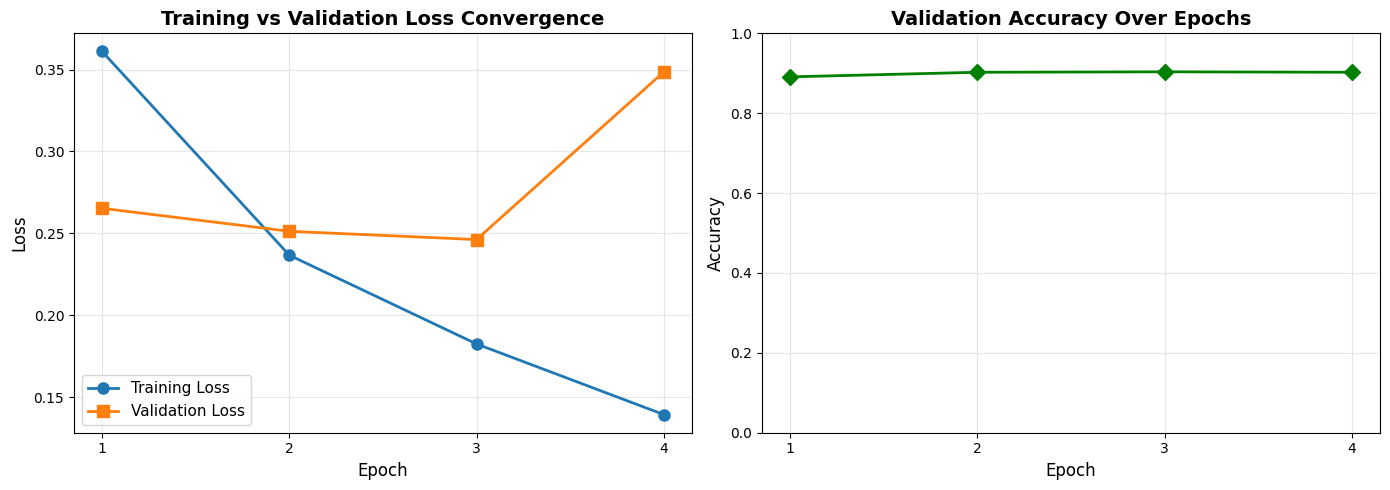


✓ Training plots saved: training_results.png


In [15]:
if not train_losses or not val_losses:
    print('No training history found. Run the training cell first.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs_range = range(1, len(train_losses) + 1)
    ax1.plot(epochs_range, train_losses, marker='o', label='Training Loss', linewidth=2, markersize=8)
    ax1.plot(epochs_range, val_losses, marker='s', label='Validation Loss', linewidth=2, markersize=8)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training vs Validation Loss Convergence', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(list(epochs_range))

    ax2.plot(epochs_range, val_accuracies, marker='D', color='green', linewidth=2, markersize=8)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(list(epochs_range))
    ax2.set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig('training_results.png', dpi=100, bbox_inches='tight')
    plt.show()

    print('\n✓ Training plots saved: training_results.png')

---
## Inference: Testing on Custom Sentences

In [16]:
def predict_sentiment(text, model, tokenizer, device):
    model.eval()

    encoding = tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    token_type_ids = encoding['token_type_ids'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask, token_type_ids)
        probs = F.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred].item()

    label = 'Positive' if pred == 1 else 'Negative'
    return label, confidence


test_sentences = [
    'The movie was absolutely fantastic!',
    'I hated it. Total waste of time.',
    'It was okay, nothing special.',
    'Amazing performance by the lead actor!',
    'Boring and predictable plot.',
    'One of the best films I\'ve ever seen!'
]

print('\n' + '=' * 70)
print('SENTIMENT PREDICTION ON CUSTOM SENTENCES')
print('=' * 70 + '\n')

for i, sentence in enumerate(test_sentences, 1):
    pred, conf = predict_sentiment(sentence, model, tokenizer, device)
    print(f'{i}. Text: {sentence}')
    print(f'   Prediction: {pred} (confidence: {conf:.4f})')
    print()

try:
    user_input_text = input('Enter a sentence to classify (press Enter for default): ').strip()
except Exception:
    user_input_text = ''

if not user_input_text:
    user_input_text = 'The movie was absolutely fantastic'

user_pred, user_conf = predict_sentiment(user_input_text, model, tokenizer, device)
print('Single input demo:')
print(f'Input: {user_input_text}')
print(f'Predicted sentiment: {user_pred} (confidence: {user_conf:.4f})')


SENTIMENT PREDICTION ON CUSTOM SENTENCES

1. Text: The movie was absolutely fantastic!
   Prediction: Positive (confidence: 0.9998)

2. Text: I hated it. Total waste of time.
   Prediction: Negative (confidence: 0.9996)

3. Text: It was okay, nothing special.
   Prediction: Negative (confidence: 0.8768)

4. Text: Amazing performance by the lead actor!
   Prediction: Positive (confidence: 0.9998)

5. Text: Boring and predictable plot.
   Prediction: Negative (confidence: 0.9996)

6. Text: One of the best films I've ever seen!
   Prediction: Positive (confidence: 0.9997)

Single input demo:
Input: The movie was absolutely fantastic
Predicted sentiment: Positive (confidence: 0.9998)


## Analysis: Why use adapters instead of full fine-tuning?

Full fine-tuning updates all 110M BERT parameters at every training step.
This creates three concrete, measurable costs:

**1. GPU Memory:** AdamW stores two additional copies of every parameter
(first and second moment estimates). For BERT-base in FP32:
  - Parameters alone:        110M x 4 bytes =  ~440 MB
  - AdamW optimizer states:  110M x 8 bytes =  ~880 MB
  - Gradients:               110M x 4 bytes =  ~440 MB
  - Total full fine-tuning:                  ~1.76 GB just for weights/gradients

  With adapters, only 1.19M parameters are trainable:
  - Adapter optimizer states: 1.19M x 8 bytes = ~9.5 MB
  - Memory saving: ~98.9% less optimizer memory

**2. Training Time:** The backward pass scales with the number of trainable
parameters. Full fine-tuning computes gradients through all 110M weights
every step. Adapters skip 109.5M of those - the frozen base model has
no gradient computation - making each step ~98x cheaper in backward pass.

**3. Checkpoint Size:** A full BERT fine-tuned checkpoint is ~440 MB per
task. With adapters, only the adapter weights (4.8 MB) and classifier
head (6 KB) need to be saved per task. Deploying 10 tasks:
  - Full fine-tuning: 10 x 440 MB = 4.4 GB
  - Adapters:         1 shared base + 10 x ~5 MB = ~490 MB total

This is why adapters are the standard PEFT solution for resource-constrained
environments like a Colab T4.

---
## Summary

In this notebook  I have implemented a full PEFT workflow for SST-2 sentiment classification:

1. I tokenize text with bert-base-uncased using a strict max length of 128.
2. I build a bottleneck adapter block (down-project, ReLU, up-project).
3. I inject adapters into BERT encoder layers and freeze base model weights.
4. I train adapters plus classifier for 4 epochs and run inference on custom text.

Main takeaway: I can adapt BERT effectively without updating all parameters, which significantly reduces compute, memory use, and checkpoint size.

In [17]:

print('=' * 70)

if val_accuracies and val_losses:
    best_epoch = int(np.argmax(val_accuracies)) + 1
    print('\nFinal Metrics:')
    print(f'  Best epoch: {best_epoch}')
    print(f'  Best validation accuracy: {max(val_accuracies):.4f}')
    print(f'  Final validation loss: {val_losses[-1]:.4f}')
    print(f'  Total trainable parameters: {trainable_params:,}')
    print(f'  Parameter efficiency: {100 * trainable_params / total_params:.3f}%')
else:
    print('\nFinal Metrics: not available yet.')
    print('Run the training cell before this summary cell.')

print('=' * 70)


Final Metrics:
  Best epoch: 3
  Best validation accuracy: 0.9037
  Final validation loss: 0.3486
  Total trainable parameters: 1,191,170
  Parameter efficiency: 1.076%
